# A figure to show the before and after af the removal of the ac stark shift
- currently imagining a figure with two side by sides of rabi and ccd with their ac stark shift removed

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [2]:
steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


## Rabi


In [13]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)



fids_rabi_raw = []
fids_rabi_compensated = []




for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)

    # calculate how the bare detuned qubit fairs
    fid_rabi_raw = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_rabi_raw.append(fid_rabi_raw)


    # then compensate for the ac stark effect and recalculate the fidelity
    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_rabi_compensated = qt.calculate_fidelities(identity, Us_effective_rabi, 2)
    fids_rabi_compensated.append(fid_rabi_compensated)



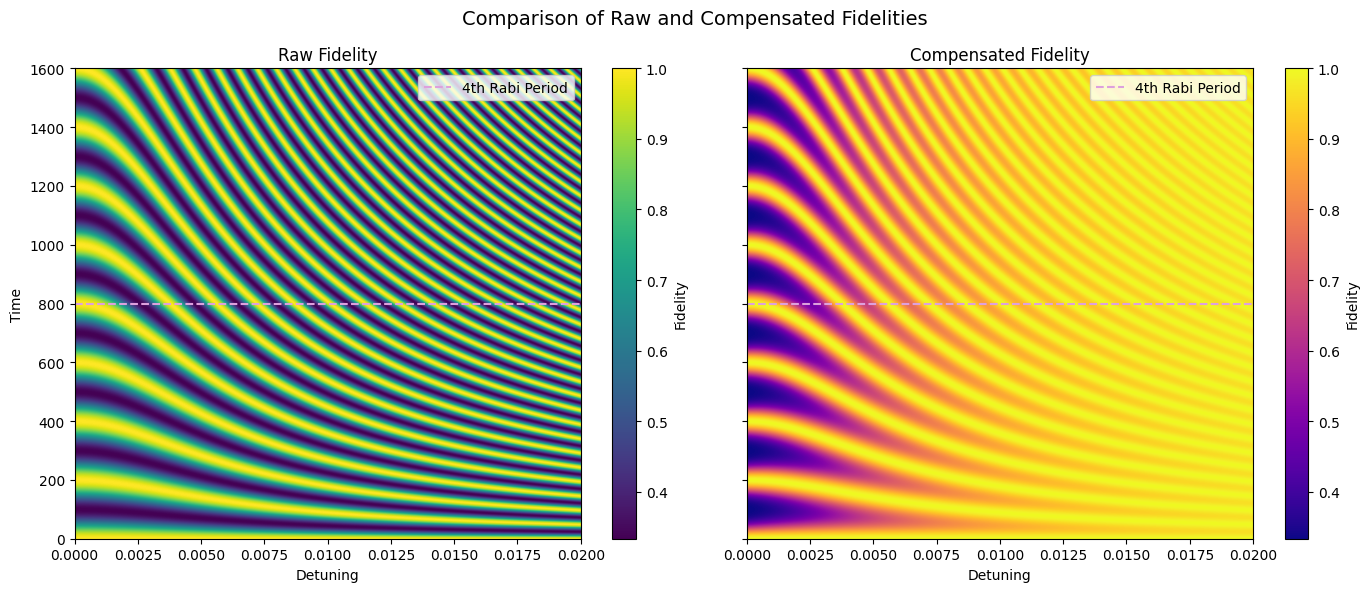

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Raw Fidelity
im0 = axs[0].imshow(
    np.array(fids_rabi_raw).T, aspect='auto',
    extent=[detunings[0], detunings[-1], 0, evaluation_time],
    origin='lower', cmap='viridis'
)
axs[0].axhline(y=4/rabi_freq, color='plum', linestyle='--', label='4th Rabi Period')
axs[0].set_title('Raw Fidelity')
axs[0].set_xlabel('Detuning')
axs[0].set_ylabel('Time')
axs[0].legend()
fig.colorbar(im0, ax=axs[0], label='Fidelity')

# Plot Compensated Fidelity
im1 = axs[1].imshow(
    np.array(fids_rabi_compensated).T, aspect='auto',
    extent=[detunings[0], detunings[-1], 0, evaluation_time],
    origin='lower', cmap='plasma'
)
axs[1].axhline(y=4/rabi_freq, color='plum', linestyle='--', label='4th Rabi Period')
axs[1].set_title('Compensated Fidelity')
axs[1].set_xlabel('Detuning')
axs[1].legend()
fig.colorbar(im1, ax=axs[1], label='Fidelity')

fig.suptitle('Comparison of Raw and Compensated Fidelities', fontsize=14)
plt.tight_layout()
plt.show()

## CCD

In [16]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)



fids_ccd_raw = []
fids_ccd_compensated = []


for detuning in detunings:
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol, rtol=tol)
    

    fid_ccd_raw = qt.calculate_fidelities(identity, Us_driving_frame, 2)
    fids_ccd_raw.append(fid_ccd_raw)
    # then compensate for the ac stark effect and recalculate the fidelity

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)
    
    fid_ccd_compensated = qt.calculate_fidelities(identity, transformed_Us, 2)


    fids_ccd_compensated.append(fid_ccd_compensated)




# now create the combined plot

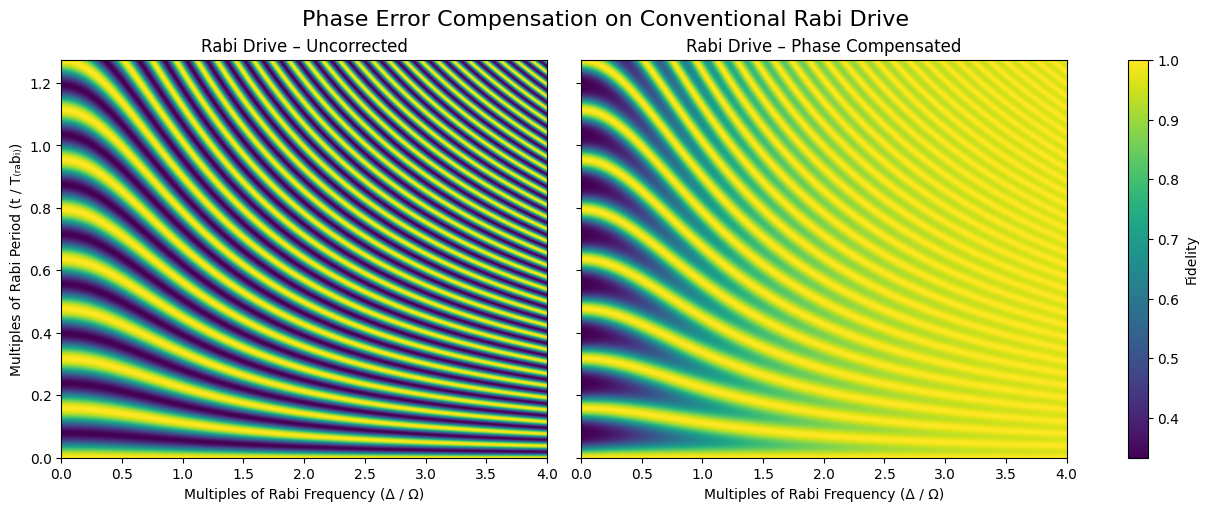

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Compute Rabi period and prepare rescaled axes
rabi_period = 2 * np.pi / rabi_freq
time_scale = np.linspace(0, evaluation_time, len(fids_rabi_raw)) / rabi_period  # in Rabi periods
detuning_scale = np.array(detunings) / rabi_freq  # in units of Rabi frequency

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)

titles = [
    'Rabi Drive – Uncorrected',
    'Rabi Drive – Phase Compensated'
]
data = [
    fids_rabi_raw,
    fids_rabi_compensated
]

# Plot
for ax, title, fid in zip(axs, titles, data):
    im = ax.imshow(
        np.array(fid).T, aspect='auto',
        extent=[detuning_scale[0], detuning_scale[-1], time_scale[0], time_scale[-1]],
        origin='lower', cmap='viridis',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title)
    ax.set_xlabel('Multiples of Rabi Frequency (Δ / Ω)')
axs[0].set_ylabel('Multiples of Rabi Period (t / T₍ᵣₐbᵢ₎)')

# Shared colorbar
cbar = fig.colorbar(im, ax=axs.ravel().tolist(), location='right', label='Fidelity')

fig.suptitle('Phase Error Compensation on Conventional Rabi Drive', fontsize=16)
fig.savefig('/Users/archie/documents/year4/project/Figures/phase_error_compensation_rabi.png', dpi=600)
plt.show()